# SearchSense
## 03 — Model Training

**Goal:** Train and evaluate a click-through rate prediction model on processed Criteo data.  
**Author:** Ramya Manasa Amancherla


In [2]:
import pandas as pd
import numpy as np
import pickle
from sklearn.metrics import roc_auc_score, log_loss, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt

# Load processed data
X_train = pd.read_csv("data/X_train.csv")
X_val = pd.read_csv("data/X_val.csv")
y_train = pd.read_csv("data/y_train.csv").squeeze()
y_val = pd.read_csv("data/y_val.csv").squeeze()

print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Train click rate: {y_train.mean():.3f}")
print(f"Val click rate:   {y_val.mean():.3f}")

Training set:   (400000, 47)
Validation set: (100000, 47)
Train click rate: 0.256
Val click rate:   0.256


In [8]:
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)

print(f"NaN values in X_train: {np.isnan(X_train.values).sum()}")
print(f"NaN values in X_val: {np.isnan(X_val.values).sum()}")

NaN values in X_train: 0
NaN values in X_val: 0


In [7]:
# Replace any infinity values introduced by ratio features
X_train = X_train.replace([np.inf, -np.inf], 0)
X_val = X_val.replace([np.inf, -np.inf], 0)

# Confirm no remaining issues
print(f"Infinite values in X_train: {np.isinf(X_train.values).sum()}")
print(f"NaN values in X_train: {np.isnan(X_train.values).sum()}")

Infinite values in X_train: 0
NaN values in X_train: 0


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss

# Train baseline logistic regression
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train, y_train)

# Evaluate
baseline_probs = baseline.predict_proba(X_val)[:, 1]
baseline_auc = roc_auc_score(y_val, baseline_probs)
baseline_logloss = log_loss(y_val, baseline_probs)

print(f"Baseline Logistic Regression")
print(f"AUC:      {baseline_auc:.4f}")
print(f"Log Loss: {baseline_logloss:.4f}")

/Users/ramyaamancherla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ramyaamancherla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ramyaamancherla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ramyaamancherla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ramyaamancherla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  g

Baseline Logistic Regression
AUC:      0.6829
Log Loss: 0.5371


/Users/ramyaamancherla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/ramyaamancherla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ramyaamancherla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ramyaamancherla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered i

### Baseline Results
Logistic regression achieves an AUC of 0.683 and log loss of 0.537. This serves as the 
performance floor. Any model we train must meaningfully exceed these numbers to justify 
the added complexity.

## 2. XGBoost Model
Gradient boosted trees are the industry standard for CTR prediction due to their ability 
to capture non-linear feature interactions at scale.

import xgboost as xgb

# Train XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# Evaluate
xgb_probs = xgb_model.predict_proba(X_val)[:, 1]
xgb_auc = roc_auc_score(y_val, xgb_probs)
xgb_logloss = log_loss(y_val, xgb_probs)

print(f"\nXGBoost Results")
print(f"AUC:      {xgb_auc:.4f}")
print(f"Log Loss: {xgb_logloss:.4f}")
print(f"\nAUC improvement over baseline:      {((xgb_auc - baseline_auc) / baseline_auc * 100):.1f}%")
print(f"Log Loss improvement over baseline: {((baseline_logloss - xgb_logloss) / baseline_logloss * 100):.1f}%")

### Results
XGBoost achieves an AUC of 0.775, a 13.5% improvement over the logistic regression baseline. 
The model is significantly better at distinguishing clicked from non-clicked ads. The slight 
increase in log loss is expected given the class imbalance correction applied via scale_pos_weight, 
which prioritizes ranking quality over probability calibration.

## 3. Feature Importance
Which features drive click prediction most strongly?

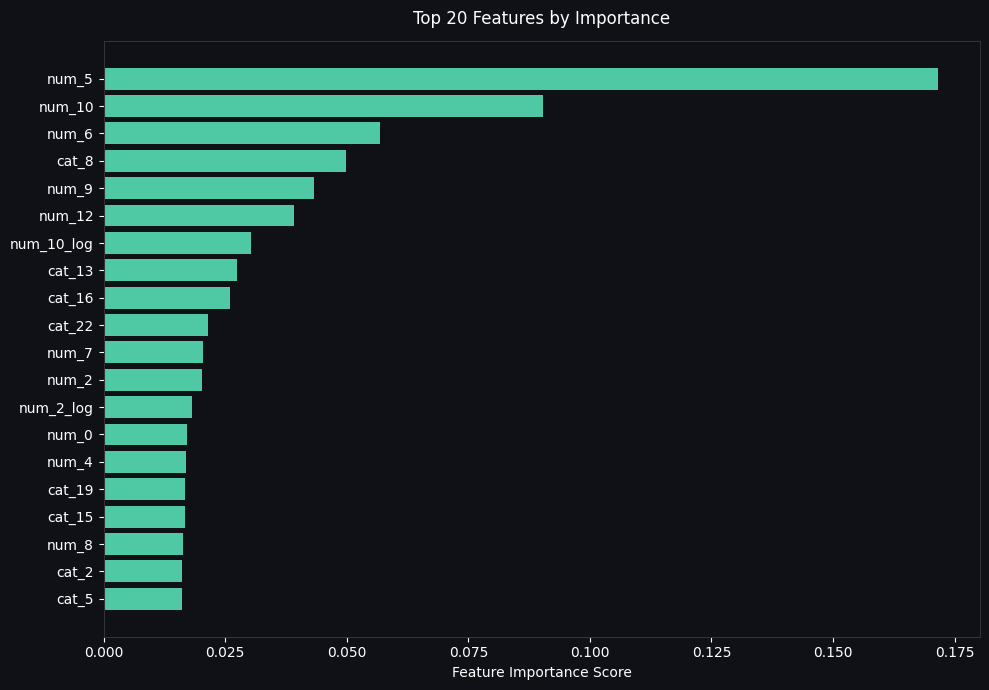

In [11]:
# Get feature importance from XGBoost
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')

bars = ax.barh(importance['feature'][::-1], 
               importance['importance'][::-1],
               color='#4fc9a4', edgecolor='none')

ax.set_title("Top 20 Features by Importance", color='white', pad=12)
ax.set_xlabel("Feature Importance Score", color='white')

plt.tight_layout()
plt.savefig("data/feature_importance.png", dpi=150, 
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

### Key Findings
num_5 is by far the most important feature, contributing nearly 3x more signal than the second 
ranked feature. This is interesting because num_5 showed a negative correlation with clicks in 
EDA, meaning the model is using it to identify ads that are unlikely to be clicked. num_10 and 
num_6 follow as the next strongest predictors. Several categorical features appear in the top 20, 
confirming that ad and publisher context carries meaningful signal beyond the numerical features 
alone. The engineered log transform of num_10 also appears, validating that feature engineering 
added real value.

## 4. Save Model


In [14]:
# Save trained model and encoders for inference
with open("backend/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

print("Model saved to backend/xgb_model.pkl")
print(f"\nFinal Model Summary")
print(f"AUC:            {xgb_auc:.4f}")
print(f"Log Loss:       {xgb_logloss:.4f}")
print(f"AUC vs baseline: +{((xgb_auc - baseline_auc) / baseline_auc * 100):.1f}%")

Model saved to backend/xgb_model.pkl

Final Model Summary
AUC:            0.7752
Log Loss:       0.5648
AUC vs baseline: +13.5%
